### Limpieza de símbolos

In [3]:
import pandas as pd

dow = pd.read_csv('../datos/dow.csv',
                    parse_dates=['Fecha'],
                    index_col = 'Fecha',
                    usecols=['Fecha', 'Diario', 'Pronóstico', 'Cambio Porcentual'])
dow.head()

/tmp/ipykernel_176811/3020654539.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dow = pd.read_csv('../datos/dow.csv',


,Diario,Pronóstico,Cambio Porcentual
Fecha,,,
2021-04-26,"$125,789.89","$235,036.46",-46.48%
2021-04-27,"$99,374.01","$197,622.55",-49.72%
2021-04-28,"$82,203.16","$116,991.26",-29.74%
2021-04-29,"$33,530.26","$66,652.65",-49.69%
2021-04-30,"$30,105.24","$34,828.19",-13.56%


In [4]:
dow.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 128 entries, 2021-04-26 to 2021-08-31
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Diario             128 non-null    str  
 1   Pronóstico         128 non-null    str  
 2   Cambio Porcentual  128 non-null    str  
dtypes: str(3)
memory usage: 4.0 KB


In [7]:
limpiar = lambda x: float(x.replace('$', '').replace('%', '').replace(',', '').replace(' ', ''))
for col in dow.columns:
    dow[col] = dow[col].apply(limpiar)

dow.head()

,Diario,Pronóstico,Cambio Porcentual
Fecha,,,
2021-04-26,125789.89,235036.46,-46.48
2021-04-27,99374.01,197622.55,-49.72
2021-04-28,82203.16,116991.26,-29.74
2021-04-29,33530.26,66652.65,-49.69
2021-04-30,30105.24,34828.19,-13.56


In [8]:
dow.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 128 entries, 2021-04-26 to 2021-08-31
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Diario             128 non-null    float64
 1   Pronóstico         128 non-null    float64
 2   Cambio Porcentual  128 non-null    float64
dtypes: float64(3)
memory usage: 4.0 KB


### Visualización

(array([18748., 18762., 18779., 18793., 18809., 18823., 18840., 18854.,
        18871.]),
 [Text(18748.0, 0, '2021-05-01'),
  Text(18762.0, 0, '2021-05-15'),
  Text(18779.0, 0, '2021-06-01'),
  Text(18793.0, 0, '2021-06-15'),
  Text(18809.0, 0, '2021-07-01'),
  Text(18823.0, 0, '2021-07-15'),
  Text(18840.0, 0, '2021-08-01'),
  Text(18854.0, 0, '2021-08-15'),
  Text(18871.0, 0, '2021-09-01')])

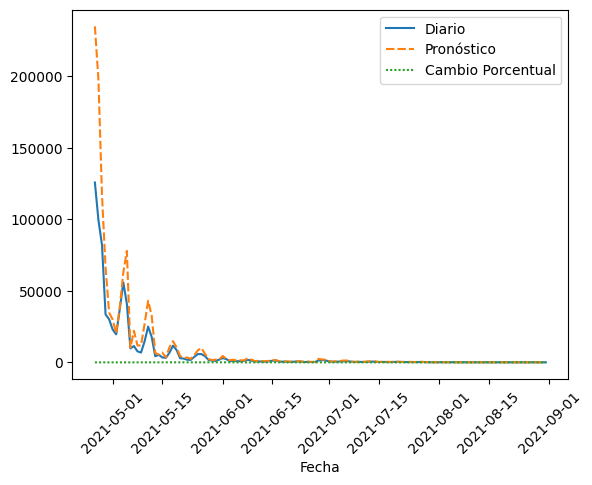

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt 

ax = sns.lineplot(dow)
plt.xticks(rotation = 45)

(array([18748., 18762., 18779., 18793., 18809., 18823., 18840., 18854.,
        18871.]),
 [Text(18748.0, 0, '2021-05-01'),
  Text(18762.0, 0, '2021-05-15'),
  Text(18779.0, 0, '2021-06-01'),
  Text(18793.0, 0, '2021-06-15'),
  Text(18809.0, 0, '2021-07-01'),
  Text(18823.0, 0, '2021-07-15'),
  Text(18840.0, 0, '2021-08-01'),
  Text(18854.0, 0, '2021-08-15'),
  Text(18871.0, 0, '2021-09-01')])

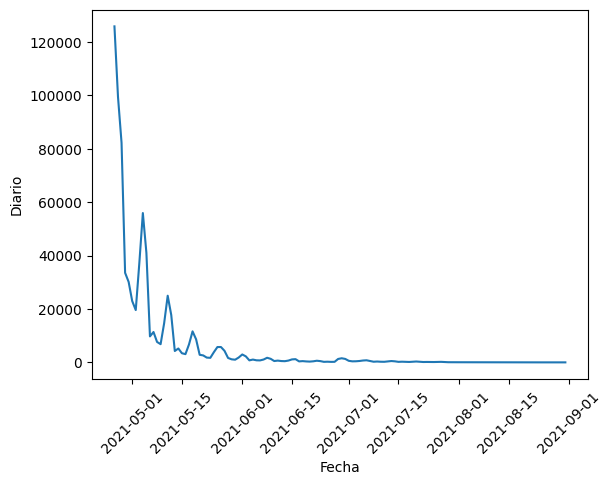

In [11]:
ax = sns.lineplot(dow['Diario'])
plt.xticks(rotation = 45)   

### Modificar las etiquetas horizontales

(array([18748., 18762., 18779., 18793., 18809., 18823., 18840., 18854.,
        18871.]),
 [Text(18748.0, 0, '05-01'),
  Text(18762.0, 0, '05-15'),
  Text(18779.0, 0, '06-01'),
  Text(18793.0, 0, '06-15'),
  Text(18809.0, 0, '07-01'),
  Text(18823.0, 0, '07-15'),
  Text(18840.0, 0, '08-01'),
  Text(18854.0, 0, '08-15'),
  Text(18871.0, 0, '09-01')])

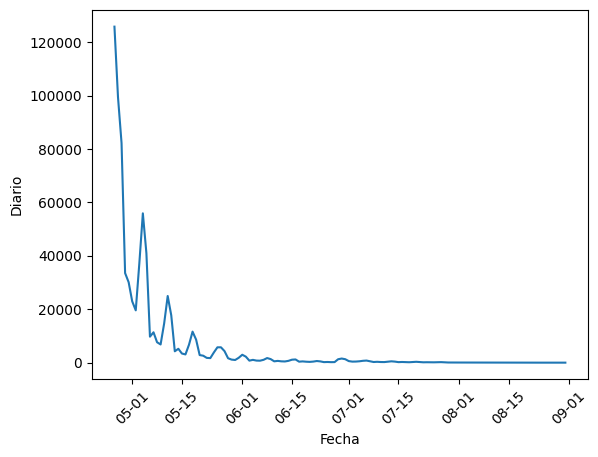

In [14]:
import matplotlib.dates as mdates

ax = sns.lineplot(dow['Diario'])
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.xticks(rotation = 45)  

(array([18748., 18762., 18779., 18793., 18809., 18823., 18840., 18854.,
        18871.]),
 [Text(18748.0, 0, 'May-01'),
  Text(18762.0, 0, 'May-15'),
  Text(18779.0, 0, 'Jun-01'),
  Text(18793.0, 0, 'Jun-15'),
  Text(18809.0, 0, 'Jul-01'),
  Text(18823.0, 0, 'Jul-15'),
  Text(18840.0, 0, 'Aug-01'),
  Text(18854.0, 0, 'Aug-15'),
  Text(18871.0, 0, 'Sep-01')])

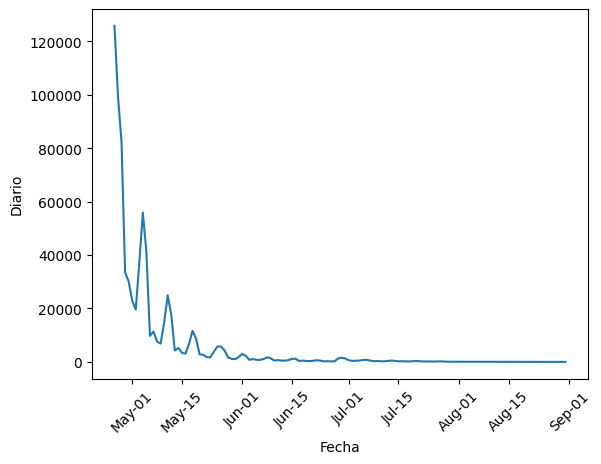

In [15]:
ax = sns.lineplot(dow['Diario'])
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
plt.xticks(rotation = 45) 

<Axes: xlabel='Fecha'>

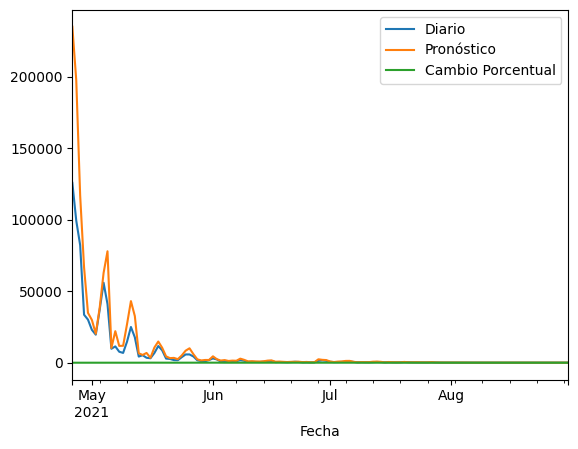

In [16]:
dow.plot()

### Fijar la periodicidad del eje x

(array([18748., 18779., 18809., 18840.]),
 [Text(18748.0, 0, 'May-01'),
  Text(18779.0, 0, 'Jun-01'),
  Text(18809.0, 0, 'Jul-01'),
  Text(18840.0, 0, 'Aug-01')])

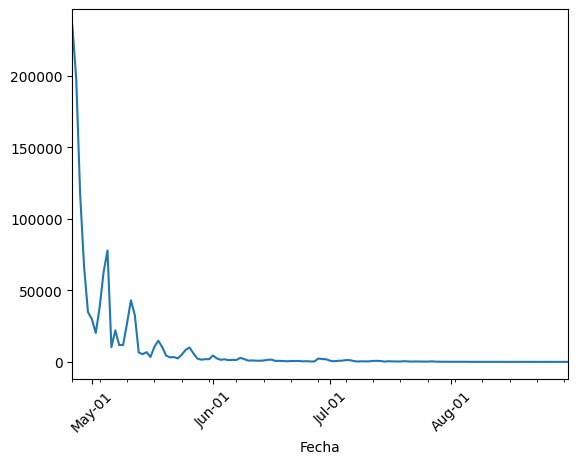

In [18]:
ax = dow['Pronóstico'].plot()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation = 45)